# Visualizing PAE matrices and distance matrices

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys 

sys.path.insert(0, str(Path(__file__).resolve().parents[1]))
from config import REPO_ROOT, PROTEOME_CSV, CHAI_MULTIMER_DIR


In [ ]:
# Chai prediction directory: must contain pred.model_idx_*.cif; PAE plots need scores.model_idx_*.npz.
run_dir = CHAI_MULTIMER_DIR / "naive_chai_homodimers_noXLs" / "homodimer_1208_TGRH88_061550" #change this as needed for any sample of interest

# Alternative: set a string and resolve, e.g. run_dir = Path("/path/to/homodimer_...").expanduser().resolve()


def _model_indices_from_cifs(d: Path) -> list[int]:
    idxs: list[int] = []
    for p in sorted(d.glob("pred.model_idx_*.cif")):
        idxs.append(int(p.stem.split("_")[-1]))
    return sorted(idxs)


model_indices = _model_indices_from_cifs(run_dir)
if not model_indices:
    raise FileNotFoundError(f"No pred.model_idx_*.cif under {run_dir}")

# --- Residue highlight (same row/column order as CA atoms in the CIF) ---
# Inclusive 0-based indices on both axes; the two endpoints can be given in either order, e.g. (5, 10) == (10, 5).
# Set to None to turn off the box.
HIGHLIGHT_RESIDUE_RANGE: tuple[int, int] | None = None

# Style for the highlight rectangle (matplotlib Rectangle kwargs).
HIGHLIGHT_BOX_KW = dict(edgecolor="lime", linewidth=2.5, zorder=10)

In [18]:
def parse_cif_ca(filepath):
    """Parse a CIF file, return CA coords and chain boundaries."""
    with open(filepath) as f:
        lines = f.readlines()

    # Find _atom_site column headers
    col_names = []
    data_start = None
    in_atom_site = False

    for i, line in enumerate(lines):
        s = line.strip()
        if s.startswith("_atom_site."):
            in_atom_site = True
            col_names.append(s)
        elif in_atom_site and s and not s.startswith("_") and not s.startswith("#"):
            data_start = i
            break

    col = {name: idx for idx, name in enumerate(col_names)}

    def g(*keys):
        for k in keys:
            if k in col:
                return col[k]
        return None

    ix = g("_atom_site.Cartn_x")
    iy = g("_atom_site.Cartn_y")
    iz = g("_atom_site.Cartn_z")
    i_atom = g("_atom_site.label_atom_id", "_atom_site.auth_atom_id")
    i_chain = g("_atom_site.auth_asym_id", "_atom_site.label_asym_id")
    i_group = g("_atom_site.group_PDB")
    i_alt = g("_atom_site.label_alt_id")
    i_model = g("_atom_site.pdbx_PDB_model_num")

    coords = []
    chain_ids = []
    first_model = None

    for i in range(data_start, len(lines)):
        s = lines[i].strip()
        if not s or s.startswith("#") or s.startswith("_") or s.startswith("loop_"):
            break
        t = s.split()
        if len(t) < len(col_names):
            continue

        if i_model is not None:
            if first_model is None:
                first_model = t[i_model]
            elif t[i_model] != first_model:
                break

        if i_group is not None and t[i_group] != "ATOM":
            continue
        if t[i_atom].strip("'\"") != "CA":
            continue
        if i_alt is not None and t[i_alt] not in (".", "?", "A"):
            continue

        coords.append([float(t[ix]), float(t[iy]), float(t[iz])])
        chain_ids.append(t[i_chain] if i_chain is not None else "A")

    coords = np.array(coords)

    # Chain boundaries: list of (chain_id, start_index, end_index)
    chains = []
    start = 0
    for i in range(1, len(chain_ids)):
        if chain_ids[i] != chain_ids[i - 1]:
            chains.append((chain_ids[i - 1], start, i))
            start = i
    chains.append((chain_ids[-1], start, len(chain_ids)))

    return coords, chains

def distance_matrix(coords):
    """Pairwise Euclidean distance matrix."""
    d = coords[:, None, :] - coords[None, :, :]
    return np.sqrt((d ** 2).sum(axis=-1))

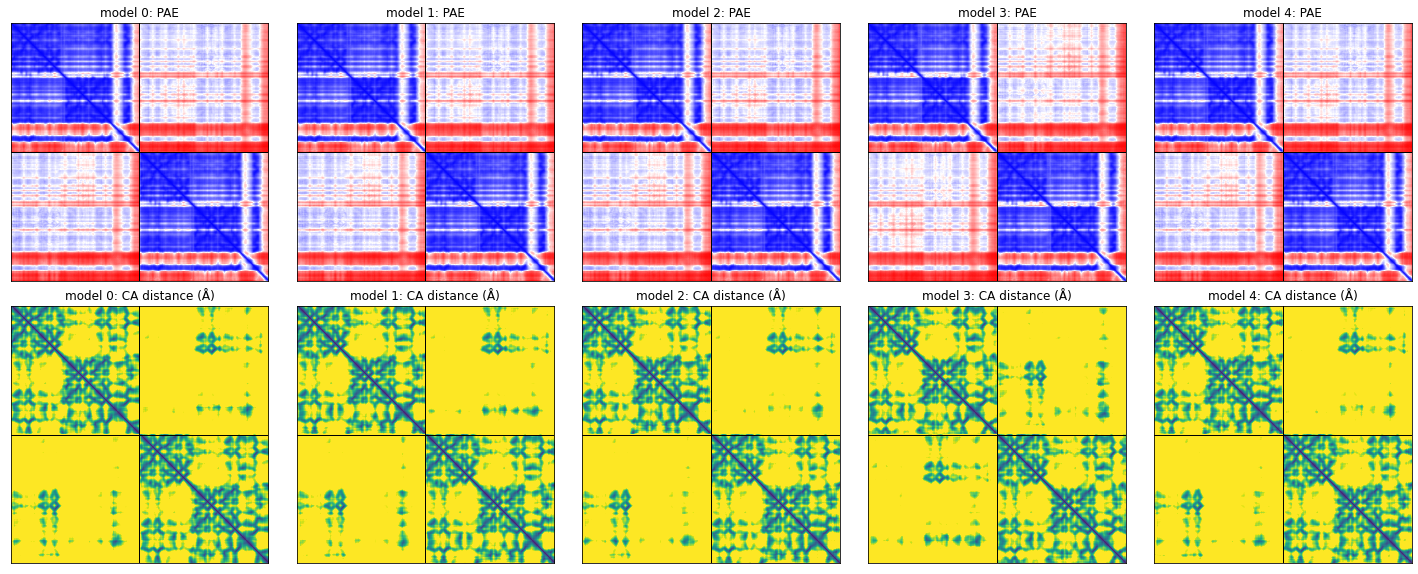

In [19]:
from matplotlib.patches import Rectangle


def _add_symmetric_highlight_box(
    ax,
    lo: int,
    hi: int,
    n: int,
    **rect_kw,
) -> None:
    """Square box over rows/columns inclusive (0-based), same on x and y. Endpoints may be given in any order."""
    lo, hi = min(lo, hi), max(lo, hi)
    if lo < 0 or hi >= n:
        return
    span = hi - lo + 1
    kw = dict(clip_on=False)
    kw.update(rect_kw)
    ax.add_patch(
        Rectangle(
            (lo - 0.5, lo - 0.5),
            span,
            span,
            fill=False,
            **kw,
        )
    )


def plot_distance_and_pae_matrices(
    run_dir: Path,
    model_indices: list[int],
    *,
    dm_vmax: float = 30.0,
    pae_vmax: float = 30.0,
    highlight_residue_range: tuple[int, int] | None = None,
    highlight_box_kw: dict | None = None,
) -> None:
    """Top row: PAE per model. Bottom row: CA distance (Å) per model. One column per model."""
    box_kw = dict(edgecolor="cyan", linewidth=2.0, zorder=10)
    if highlight_box_kw:
        box_kw |= highlight_box_kw

    n = len(model_indices)
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 8), squeeze=False)

    for col, midx in enumerate(model_indices):
        cif_p = run_dir / f"pred.model_idx_{midx}.cif"
        npz_p = run_dir / f"scores.model_idx_{midx}.npz"
        ca, ch = parse_cif_ca(cif_p)
        dm = distance_matrix(ca)
        n_res = dm.shape[0]

        ax_p = axes[0, col]
        ax_p.set_title(f"model {midx}: PAE")
        ax_p.set_aspect("equal")
        if not npz_p.is_file():
            ax_p.text(
                0.5,
                0.5,
                f"missing\n{npz_p.name}",
                ha="center",
                va="center",
                transform=ax_p.transAxes,
            )
            ax_p.axis("off")
        else:
            pae = np.load(npz_p)["pae"]
            ax_p.imshow(pae, vmin=0, vmax=pae_vmax, cmap="bwr")
            for _, start, _ in ch:
                if start > 0:
                    ax_p.axhline(start - 0.5, color="black", lw=1)
                    ax_p.axvline(start - 0.5, color="black", lw=1)
            ax_p.set_xticks([])
            ax_p.set_yticks([])
            if highlight_residue_range is not None:
                lo, hi = highlight_residue_range
                if pae.shape[0] == pae.shape[1] == n_res:
                    _add_symmetric_highlight_box(ax_p, lo, hi, n_res, **box_kw)

        ax_d = axes[1, col]
        ax_d.set_title(f"model {midx}: CA distance (Å)")
        ax_d.set_aspect("equal")
        ax_d.imshow(dm, vmin=0, vmax=dm_vmax)
        for _, start, _ in ch:
            if start > 0:
                ax_d.axhline(start - 0.5, color="black", lw=1)
                ax_d.axvline(start - 0.5, color="black", lw=1)
        ax_d.set_xticks([])
        ax_d.set_yticks([])
        if highlight_residue_range is not None:
            lo, hi = highlight_residue_range
            _add_symmetric_highlight_box(ax_d, lo, hi, n_res, **box_kw)

    fig.tight_layout()


plot_distance_and_pae_matrices(
    run_dir,
    model_indices,
    highlight_residue_range=HIGHLIGHT_RESIDUE_RANGE,
    highlight_box_kw=HIGHLIGHT_BOX_KW,
)